In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from google.cloud import bigquery
from google.oauth2 import service_account

KEYFILE = r"C:\Users\sansk\Documents\Spring-26\gcp_secret_service\damagereport-499916-f3d6c433577c.json"
PROJECT = "damagereport-499916"

creds = service_account.Credentials.from_service_account_file(
    KEYFILE,
    scopes=["https://www.googleapis.com/auth/cloud-platform"],
)
client = bigquery.Client(project=PROJECT, credentials=creds)

print("Connected")

Connected


In [10]:
query = """
    SELECT
        event_year,
        SUM(event_count)                                           AS total_events,
        SAFE_DIVIDE(SUM(total_damage_2024_usd), SUM(event_count)) AS avg_damage_per_event,
        SUM(total_damage_2024_usd)                                 AS total_damage,
        SUM(total_deaths_direct)                                   AS total_deaths
    FROM `damagereport-499916.dbt_marts.mart_severity_trends`
    GROUP BY event_year
    ORDER BY event_year
"""

df_years = client.query(query).result().to_dataframe()
print(f"Shape: {df_years.shape}")
df_years.describe()

C:\Users\sansk\Documents\Spring-26\DamageReport\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Shape: (30, 5)


,event_year,total_events,avg_damage_per_event,total_damage,total_deaths
count,30.0,30.0,3.000000e+01,3.000000e+01,30.0
mean,2010.5,59357.666667,5.216544e+05,3.010530e+10,642.966667
std,8.803408,9009.604118,5.758824e+05,3.166923e+10,251.08049
min,1996.0,41991.0,6.424961e+04,4.649102e+09,370.0
25%,2003.25,52545.75,2.602043e+05,1.640214e+10,480.5
50%,2010.5,58459.0,3.507899e+05,1.997893e+10,537.0
75%,2017.75,64079.5,5.294562e+05,3.250936e+10,749.5
max,2025.0,79091.0,2.995763e+06,1.616993e+11,1451.0


In [12]:
df_years.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_year            30 non-null     Int64  
 1   total_events          30 non-null     Int64  
 2   avg_damage_per_event  30 non-null     float64
 3   total_damage          30 non-null     float64
 4   total_deaths          30 non-null     Int64  
dtypes: Int64(3), float64(2)
memory usage: 1.4 KB


In [13]:
df_years.describe()

,event_year,total_events,avg_damage_per_event,total_damage,total_deaths
count,30.0,30.0,3.000000e+01,3.000000e+01,30.0
mean,2010.5,59357.666667,5.216544e+05,3.010530e+10,642.966667
std,8.803408,9009.604118,5.758824e+05,3.166923e+10,251.08049
min,1996.0,41991.0,6.424961e+04,4.649102e+09,370.0
25%,2003.25,52545.75,2.602043e+05,1.640214e+10,480.5
50%,2010.5,58459.0,3.507899e+05,1.997893e+10,537.0
75%,2017.75,64079.5,5.294562e+05,3.250936e+10,749.5
max,2025.0,79091.0,2.995763e+06,1.616993e+11,1451.0


In [14]:
features = ['total_events', 'avg_damage_per_event', 'total_deaths']

X = df_years[features].astype(float).copy()
X_log = np.log1p(X)  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

iso = IsolationForest(contamination=0.1, random_state=42)
df_years['anomaly_score'] = iso.fit_predict(X_scaled)
df_years['anomaly_raw_score'] = iso.score_samples(X_scaled)

anomalies = df_years[df_years['anomaly_score'] == -1].sort_values('anomaly_raw_score')
print(f"Anomalous years flagged: {len(anomalies)}")
print(anomalies[['event_year', 'total_events', 'avg_damage_per_event', 'total_deaths', 'anomaly_raw_score']])

Anomalous years flagged: 3
    event_year  total_events  avg_damage_per_event  total_deaths  \
9         2005         53976          2.995763e+06          1451   
29        2025         72360          6.424961e+04           628   
15        2011         79091          4.175877e+05          1096   

    anomaly_raw_score  
9           -0.670063  
29          -0.582155  
15          -0.563774  


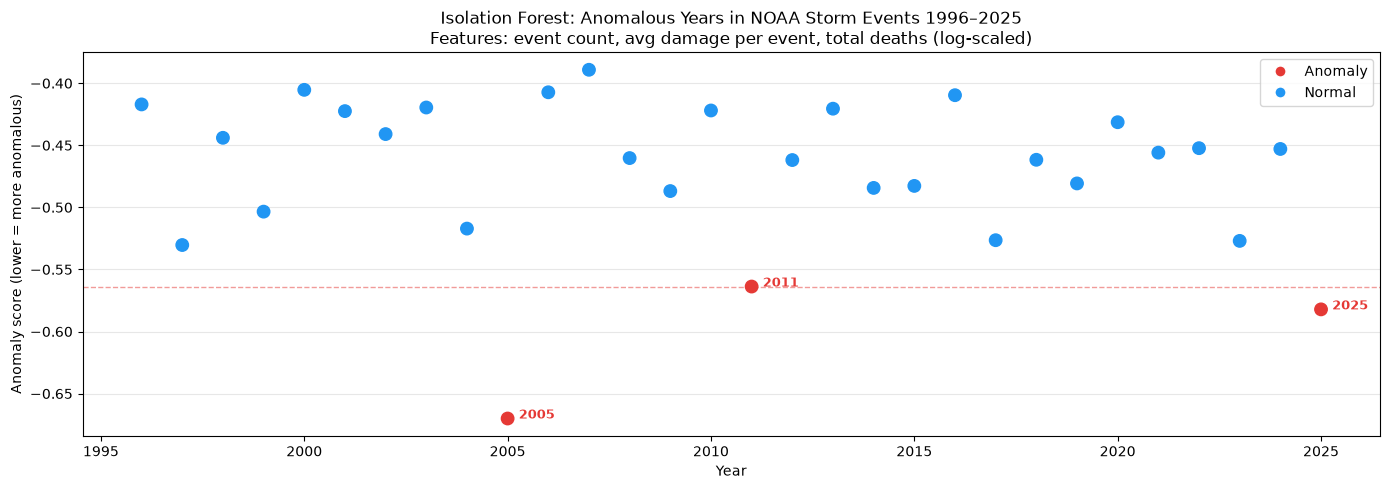

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = df_years['anomaly_score'].map({1: '#2196F3', -1: '#E53935'})

ax.scatter(df_years['event_year'], df_years['anomaly_raw_score'],
           c=colors, s=80, zorder=3)
ax.axhline(df_years[df_years['anomaly_score'] == -1]['anomaly_raw_score'].max(),
           color='#E53935', linewidth=1, linestyle='--', alpha=0.5, label='Anomaly threshold')

for _, row in anomalies.iterrows():
    ax.annotate(
        str(int(row['event_year'])),
        xy=(row['event_year'], row['anomaly_raw_score']),
        xytext=(8, 0), textcoords='offset points',
        fontsize=9, color='#E53935', fontweight='bold'
    )

ax.set_xlabel('Year')
ax.set_ylabel('Anomaly score (lower = more anomalous)')
ax.set_title('Isolation Forest: Anomalous Years in NOAA Storm Events 1996–2025\n'
             'Features: event count, avg damage per event, total deaths (log-scaled)')
ax.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#E53935', markersize=8, label='Anomaly'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3', markersize=8, label='Normal'),
])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
print("""
ANOMALY DETECTION FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Dataset : NOAA Storm Events, 1996–2025 (30 years)
Method  : Isolation Forest (unsupervised)
Features: event count, avg damage per event, total deaths
          (log-transformed → StandardScaler)
Contamination parameter: 0.10 (expect ~10% anomalies)

FLAGGED YEARS
  2005  score=-0.670  Hurricane Katrina: extreme damage per event ($3M avg)
  2011  score=-0.563  Joplin tornado season: peak event count (79K) + high deaths (1,096)
  2025  score=-0.582  Partial year: anomalously low damage per event ($64K), data still filing

INTERPRETATION
  Normal years cluster in anomaly score range [-0.40, -0.55].
  2005 is the clear outlier 6x average damage per event.
  2011 is anomalous on two dimensions simultaneously (frequency + lethality).
  2025 is anomalous in the opposite direction so a data completeness artifact,
  not a real-world event. This illustrates that anomaly detection flags
  deviation from the norm in any direction, not just extremes.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


ANOMALY DETECTION FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Dataset : NOAA Storm Events, 1996–2025 (30 years)
Method  : Isolation Forest (unsupervised)
Features: event count, avg damage per event, total deaths
          (log-transformed → StandardScaler)
Contamination parameter: 0.10 (expect ~10% anomalies)

FLAGGED YEARS
  2005  score=-0.670  Hurricane Katrina: extreme damage per event ($3M avg)
  2011  score=-0.563  Joplin tornado season: peak event count (79K) + high deaths (1,096)
  2025  score=-0.582  Partial year: anomalously low damage per event ($64K), data still filing

INTERPRETATION
  Normal years cluster in anomaly score range [-0.40, -0.55].
  2005 is the clear outlier 6x average damage per event.
  2011 is anomalous on two dimensions simultaneously (frequency + lethality).
  2025 is anomalous in the opposite direction so a data completeness artifact,
  not a real-world event. This illustrates that anomaly detection flags
  deviation from the norm in any direc